# The "Style Matchup" Predictor

## Project Direction & Novelty
Instead of looking at teams in a vacuum and predicting wins/losses on raw stats, we frame our predictive task around **stylistic clashes**. What happens when an "Elite Offense" plays an "Elite Defense"? 

**Our Approach:**
1. **Unsupervised Learning (Custering):** Group teams into playstyles first based on rolling averages of their advanced stats (e.g., Pure Offense, Gritty Defense, Balanced, Pace-Pushers).
2. **Exploratory Data Analysis (EDA):** Build a narrative identifying which historical and modern teams fit these archetypes, and how the prevalence of these styles has changed over time.
3. **Predictive Modeling:** Build a model to evaluate outcome probabilities when different styles collide in head-to-head match-ups.

### 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

# Set plotting style
sns.set_theme(style="whitegrid")

### 2. Data Loading
We load the NBA statistics dataset and filter down to the Regular Season.

In [2]:
# Download latest version of the historical NBA data
path = kagglehub.dataset_download("eoinamoore/historical-nba-data-and-player-box-scores")
print("Path to dataset files:", path)

# Load Team Extended Statistics
nba_team_stats_df = pd.read_csv(path + "/TeamStatisticsExtended.csv")

# Filter for Regular Season games only and drop unnecessary columns
nba_team_stats_df = nba_team_stats_df[nba_team_stats_df['gameType'] == 'Regular Season'].copy()
nba_team_stats_df = nba_team_stats_df.drop(columns=['gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber'])

print(f"Data Shape: {nba_team_stats_df.shape}")
nba_team_stats_df.head()

Path to dataset files: C:\Users\ragha\.cache\kagglehub\datasets\eoinamoore\historical-nba-data-and-player-box-scores\versions\496
Data Shape: (67430, 100)


,gameId,gameDateTimeEst,teamId,teamCity,teamName,opponentTeamId,opponentTeamCity,opponentTeamName,home,win,...,percentUnassisted2PointMade,percentAssisted3PointMade,percentUnassisted3PointMade,percentAssistedFieldGoalsMade,percentUnassistedFieldGoalsMade,freeThrowAttemptRate,opponentEffectiveFieldGoalPercentage,opponentFreeThrowAttemptRate,opponentTurnoverPercentage,opponentOffensiveReboundPercentage
168,22501193,2026-04-12 20:30:00,1610612741,Chicago,Bulls,1610612742,Dallas,Mavericks,0,0,...,0.524,1.000,0.000,0.577,0.423,0.179,0.630,0.270,0.162,0.365
169,22501193,2026-04-12 20:30:00,1610612742,Dallas,Mavericks,1610612741,Chicago,Bulls,1,1,...,0.533,0.955,0.045,0.673,0.327,0.270,0.538,0.179,0.116,0.288
170,22501194,2026-04-12 20:30:00,1610612763,Memphis,Grizzlies,1610612745,Houston,Rockets,0,0,...,0.423,0.615,0.385,0.590,0.410,0.105,0.524,0.286,0.107,0.452
171,22501194,2026-04-12 20:30:00,1610612745,Houston,Rockets,1610612763,Memphis,Grizzlies,1,1,...,0.647,0.786,0.214,0.479,0.521,0.286,0.479,0.105,0.126,0.179
172,22501195,2026-04-12 20:30:00,1610612740,New Orleans,Pelicans,1610612750,Minnesota,Timberwolves,0,0,...,0.625,1.000,0.000,0.444,0.556,0.355,0.562,0.483,0.102,0.308


### 3. Data Preprocessing (Rolling Averages)
To properly identify a team's "Style", we shouldn't use seasonal cumulative stats right away. We will calculate a 10-game rolling average of key performance indicators (like `offensiveRating`, `defensiveRating`, `pace`, etc.) to represent a team's current form before feeding them into our clustering algorithm.

In [5]:
# Define the advanced metrics we want to use to define a team's style
style_features = [
    'offensiveRating', 
    'defensiveRating', 
    'pace',
    'reboundPercentage', 
    'assistPercentage',
    'trueShootingPercentage',
    'teamTurnoverPercentage'
]

# Ensure date is a proper datetime object for chronologically sorting
nba_team_stats_df['gameDateTimeEst'] = pd.to_datetime(nba_team_stats_df['gameDateTimeEst'])

# Sort by team and date to keep the chronological order
nba_team_stats_df = nba_team_stats_df.sort_values(by=['teamId', 'gameDateTimeEst']).reset_index(drop=True)

# Important: We must shift the data by 1 game so that the prediction of a game
# ONLY relies on the 10 games BEFORE it, ensuring no data leakage. 
window = 10
rolling_features_df = nba_team_stats_df.groupby('teamId')[style_features].transform(
    lambda x: x.shift(1).rolling(window=window, min_periods=window).mean()
)

# Rename the new columns clearly
rolling_col_names = [f"{col}_rolling_{window}" for col in style_features]
rolling_features_df.columns = rolling_col_names

# Concatenate back to the main DataFrame
nba_team_stats_df = pd.concat([nba_team_stats_df, rolling_features_df], axis=1)

# Drop rows (like the first 10 games of the team's history) where rolling stats are NaN
nba_team_stats_df = nba_team_stats_df.dropna(subset=rolling_col_names)

print(f"Data Shape after dropping first 10 games: {nba_team_stats_df.shape}")
nba_team_stats_df[['teamName', 'gameDateTimeEst'] + rolling_col_names].head()

Data Shape after dropping first 10 games: (21464, 107)


,teamName,gameDateTimeEst,offensiveRating_rolling_10,defensiveRating_rolling_10,pace_rolling_10,reboundPercentage_rolling_10,assistPercentage_rolling_10,trueShootingPercentage_rolling_10,teamTurnoverPercentage_rolling_10
10,Hawks,1996-11-19 19:30:00,98.64,100.70,88.600,0.4987,0.5335,0.5100,0.1935
11,Hawks,1996-11-21 20:30:00,97.34,99.17,87.800,0.4946,0.5511,0.4994,0.1864
12,Hawks,1996-11-23 18:00:00,96.95,96.35,87.600,0.4970,0.5453,0.4957,0.1808
32,Hawks,1997-01-13 19:30:00,103.83,99.96,88.185,0.5003,0.4893,0.5241,0.1685
33,Hawks,1997-01-14 19:30:00,105.11,100.56,85.985,0.4960,0.5011,0.5270,0.1597


### 4. Defining "Style" (Unsupervised Learning)
Now that we have 10-game rolling averages representing how a team is *currently* playing going into a matchup, we will use **K-Means Clustering** to separate these forms into distinct basketball archetypes (e.g., Pure Offense, Gritty Defense).

First, we need to scale the data, as K-Means relies on distance metrics.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Scale the rolling features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(nba_team_stats_df[rolling_col_names])

# 2. Fit K-Means
# We start with k=4 as a hypothesis for 4 main playstyles 
# (e.g. Elite Offense, Elite Defense, Balanced, Bad)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
nba_team_stats_df['playstyle_cluster'] = kmeans.fit_predict(scaled_features)

# Let's inspect the average stats of each cluster to manually label them
cluster_analysis = nba_team_stats_df.groupby('playstyle_cluster')[rolling_col_names].mean()
cluster_analysis

,offensiveRating_rolling_10,defensiveRating_rolling_10,pace_rolling_10,reboundPercentage_rolling_10,assistPercentage_rolling_10,trueShootingPercentage_rolling_10,teamTurnoverPercentage_rolling_10
playstyle_cluster,,,,,,,
0,112.058128,116.029003,100.283170,0.480456,0.632774,0.573596,0.136900
1,107.662571,109.699772,99.489966,0.500817,0.584126,0.550811,0.145942
2,102.845655,103.395182,92.637321,0.502117,0.598953,0.523563,0.160508
3,116.953106,111.520624,99.581149,0.514537,0.621521,0.594697,0.138256


### 5. Creating the Matchup Dataset (Target Variable)
To predict actual game outcomes based on styles, we need to transform our team-level dataset into a **game-level matchup dataset**. Each row should represent a single game, containing Team A's cluster vs Team B's cluster, and whether Team A won (Target formulation).

---
## 6. Exploratory Data Analysis (EDA) & The Narrative
*(Project Requirement: EDA, Basic Stats, Properties, Interesting findings that motivate model design)*

- **Mapping Clusters to "Styles"**: What real NBA archetypes do our clusters represent? (e.g., Cluster 0 = Elite Defense, Cluster 1 = 3-Point Heavy / Pace Pushers).
- **Evolution of Styles**: Generating stacked bar charts to see how team playstyles have changed over the decades. Are Defensive structures dying out? 
- **Interesting Findings**: Highlighting historic teams (e.g., '04 Pistons, '16 Warriors) and seeing where they fit. Do styles predict success historically before we even run our ML model?

In [10]:
# 6.1 Mapping Clusters to Human-Readable Playstyles
# Based on the results in Section 4, we define our styles:
style_mapping = {
    0: "Run & Gun / Soft Defense",
    1: "Balanced / ISO-Heavy",
    2: "Grit & Grind / Slow Pace",
    3: "Elite Offense / Juggernauts"
}

nba_team_stats_df['playstyle_name'] = nba_team_stats_df['playstyle_cluster'].map(style_mapping)

print("Distribution of Playstyles across all historical games:")
playstyle_counts = nba_team_stats_df['playstyle_name'].value_counts()
print(playstyle_counts)

Distribution of Playstyles across all historical games:
playstyle_name
Elite Offense / Juggernauts    6767
Balanced / ISO-Heavy           6681
Run & Gun / Soft Defense       5374
Grit & Grind / Slow Pace       2642
Name: count, dtype: int64


<Figure size 1500x700 with 0 Axes>

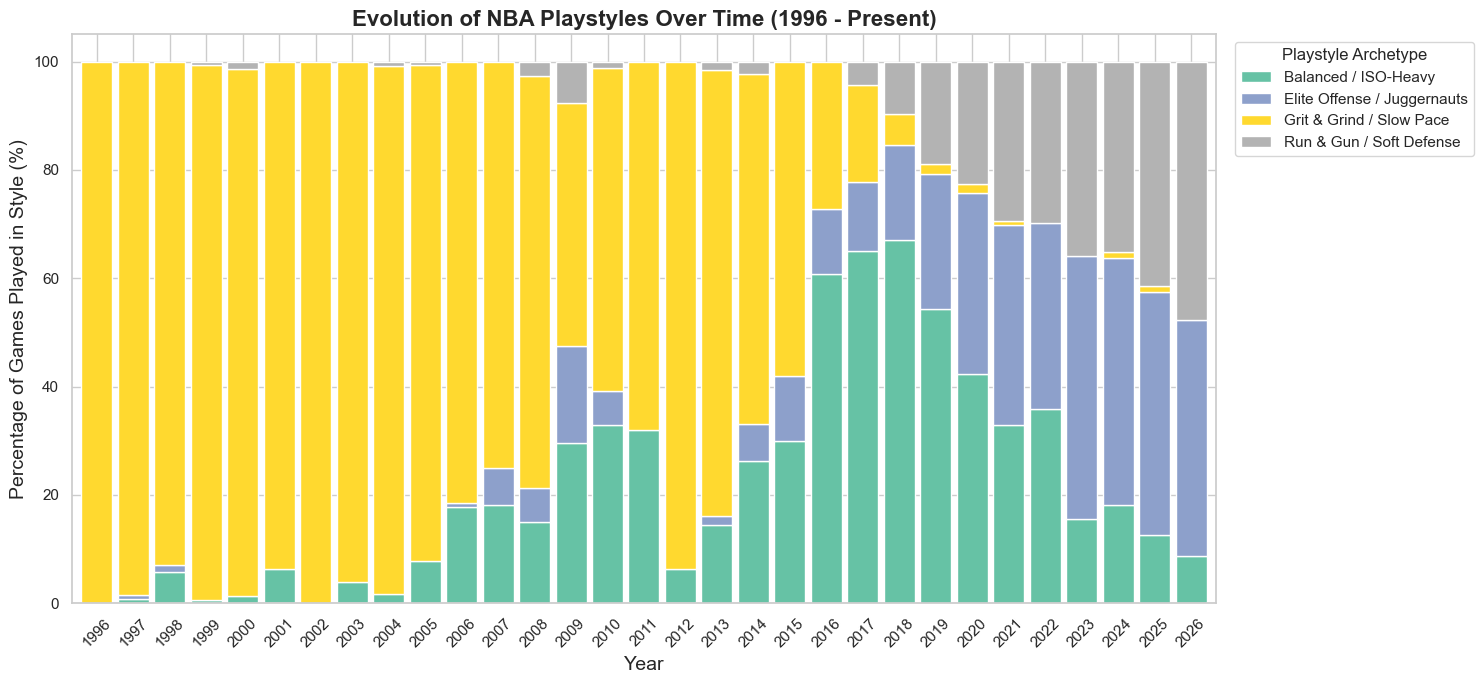

In [11]:
# 6.2 Evolution of Playstyles Over Time
# Let's visualize how the NBA has transformed from a defensive league to an offensive one
nba_team_stats_df['Year'] = nba_team_stats_df['gameDateTimeEst'].dt.year

# Group by Year and Playstyle to get raw game counts
style_by_year = nba_team_stats_df.groupby(['Year', 'playstyle_name']).size().unstack(fill_value=0)

# Normalize to get percentages out of 100%
style_by_year_perc = style_by_year.div(style_by_year.sum(axis=1), axis=0) * 100

# Plotting the 100% Stacked Bar Chart
plt.figure(figsize=(15, 7))
style_by_year_perc.plot(kind='bar', stacked=True, colormap='Set2', figsize=(15, 7), width=0.85)

plt.title('Evolution of NBA Playstyles Over Time (1996 - Present)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Percentage of Games Played in Style (%)', fontsize=14)
plt.legend(title='Playstyle Archetype', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_22116\3178062728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rates_by_style.values, y=win_rates_by_style.index, palette='viridis')


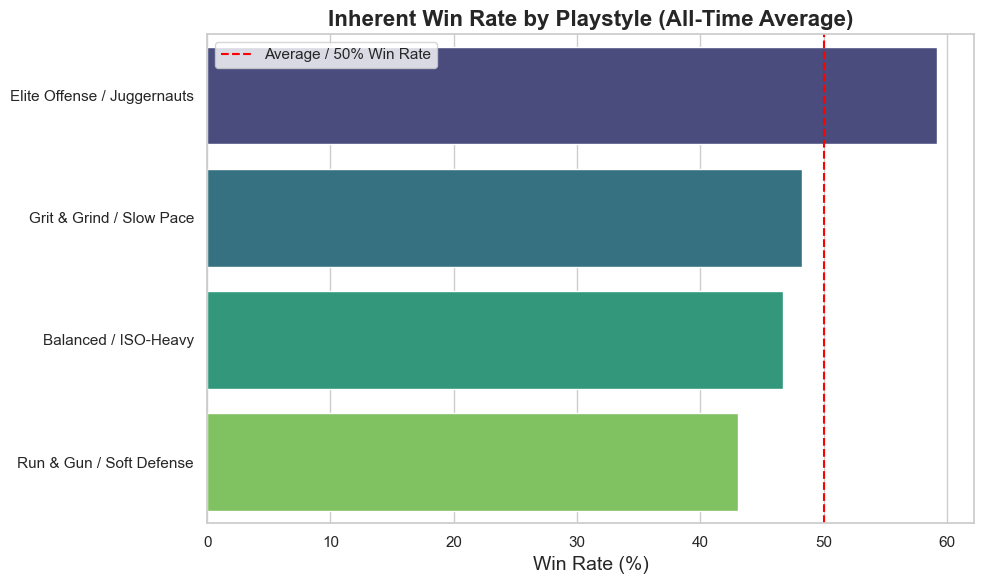

In [12]:
# 6.3 Baseline Win Rates Over All Eras
# Are certain styles inherently more successful in a vacuum, regardless of who they play?
# We convert boolean target 'win' to int (1, 0)
nba_team_stats_df['win'] = nba_team_stats_df['win'].astype(int)

win_rates_by_style = nba_team_stats_df.groupby('playstyle_name')['win'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=win_rates_by_style.values, y=win_rates_by_style.index, palette='viridis')
plt.title('Inherent Win Rate by Playstyle (All-Time Average)', fontsize=16, fontweight='bold')
plt.xlabel('Win Rate (%)', fontsize=14)
plt.ylabel('')
plt.axvline(50, color='red', linestyle='--', label='Average / 50% Win Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 6.4 Validating our Model with Historic NBA Archetypes
# To ensure our KMeans actually reflects basketball knowledge, let's pull 
# 3 distinctly famous teams and check what "Style" it assigned them at their peak

iconic_teams_filter = (
    ((nba_team_stats_df['teamName'] == 'Warriors') & (nba_team_stats_df['Year'] == 2017)) | # Steph Curry MVP Era string
    ((nba_team_stats_df['teamName'] == 'Pistons') & (nba_team_stats_df['Year'] == 2004)) |             # Ultimate defense team
    ((nba_team_stats_df['teamName'] == 'Suns') & (nba_team_stats_df['Year'] == 2007))                  # "7 Seconds or Less" offense
)

iconic_teams_df = nba_team_stats_df[iconic_teams_filter]

# Get the most common playstyle classification for that team for that entire year
historic_validation = iconic_teams_df.groupby(['Year', 'teamName'])['playstyle_name'].agg(
    lambda x: x.mode()[0]
).reset_index()

historic_validation.rename(columns={'playstyle_name': 'Assigned Playstyle (KMeans)'})

,Year,teamName,Assigned Playstyle (KMeans)
0,2004,Pistons,Grit & Grind / Slow Pace
1,2007,Suns,Elite Offense / Juggernauts
2,2017,Warriors,Elite Offense / Juggernauts


---
## 7. Related Work & Task Novelty
*(Project Requirement: Prior studies, usage of dataset, SOTA, our major novelty)*

- **Prior Work & Datasets**: Standard models on this dataset often try to predict binaries using raw rolling averages. State of the Art (SOTA) in sports analytics leans heavily into advanced modeling (Elo ratings, deep learning) but often ignores the contextual clash of playstyles.
- **Our Novelty**: Moving away from standard ablation studies ("does offense matter more than defense?") into **interaction-driven modeling**. We are arguing that a team's win probability is non-linear and depends heavily on the *opposing team's structure*.

---
## 8. Identifying the Predictive Task & Baselines
*(Project Requirement: What is the task, baselines, why out-perform?)*

- **The Predictive Task**: Binary Classification — Given Team A's cluster form and Team B's cluster form, predict if Team A wins. 
- **Baseline Models**:
  - *Baseline 1*: Naive prediction. The Home Team always wins (usually ~58-60% accuracy in the NBA).
  - *Baseline 2*: Higher win-percentage team always wins.
  - *Baseline 3*: Logistic Regression based only on points scored (pure offensive model logic).
- **Why we will outperform**: Stylistic matchups inherently contain non-linear interactions. A "Pace Pusher" might always beat an "Elite Offense," but lose to a "Gritty Defense." Our model captures this Rock-Paper-Scissors metric better than raw stats.

---
## 9. Model Proposal, Optimization & Design
*(Project Requirement: Propose model, features designed, optimization, 3rd party libs, troubles (overfitting/scalability))*

- **Proposed Models**:
  - We will use **XGBoost (or Random Forest)** for classification because tree-based models naturally handle categorical interaction terms (like Cluster A vs Cluster B) much better than linear models.
- **Features**: `Team_A_Cluster`, `Team_B_Cluster`, `Home_Court`, `Fatigue_Factor` (games played last X days).
- **Optimization**: We will optimize hyper-parameters (e.g., max_depth, learning_rate) using **GridSearchCV** or **Optuna** (3rd party libraries).
- **Addressing Challenges**: How we handled the scalability of matching pairwise games across decades, and ensuring we used rolling windows to absolutely avoid *data leakage* (overfitting to past statistics).

---
## 10. Evaluation & Results
*(Project Requirement: Does it outperform? Why/why not? Gap significance, effectiveness of features, takeaways)*

- **Performance Meta-metrics**: Checking our model against the baselines using Accuracy, F1-Score, and ROC-AUC. 
- **Feature Significance**: Using **SHAP Values** to explain *why* the model made its choice. Is mapping the "Style" of an opponent truly the defining feature?
- **Conclusion/Takeaways**: Answering our originally posed question. Does "Elite Offense" fundamentally break standard defensive setups in the modern NBA, or is "Defense Wins Championships" still statistically viable in style head-to-heads?